# Regresión Polinomial

Este notebook presenta la resolución detallada de ejercicios de regresión polinomial.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
%matplotlib inline


## 0. Análisis Inmobiliario: Casas en Tulum

**Objetivo:** Predecir el precio de propiedades basándose en metros cuadrados, habitaciones y distancia.


In [3]:
datos_tulum = {
    'Metros_Cuadrados': [120, 85, 200, 150, 95, 175, 110, 130, 160, 100],
    'Habitaciones': [3, 2, 4, 3, 2, 4, 3, 3, 3, 2],
    'Distancia_km': [5, 8, 2, 6, 10, 3, 7, 4, 5, 9],
    'Precio_miles': [250, 180, 400, 290, 150, 350, 220, 270, 310, 170]
}
df_tulum = pd.DataFrame(datos_tulum)
display(df_tulum)


,Metros_Cuadrados,Habitaciones,Distancia_km,Precio_miles
0,120,3,5,250
1,85,2,8,180
2,200,4,2,400
3,150,3,6,290
4,95,2,10,150
5,175,4,3,350
6,110,3,7,220
7,130,3,4,270
8,160,3,5,310
9,100,2,9,170


In [4]:
X_tulum = df_tulum[['Metros_Cuadrados', 'Habitaciones', 'Distancia_km']]
y_tulum = df_tulum['Precio_miles']
poly_tulum = PolynomialFeatures(degree=2)
X_t_poly = poly_tulum.fit_transform(X_tulum)
model_tulum = LinearRegression().fit(X_t_poly, y_tulum)


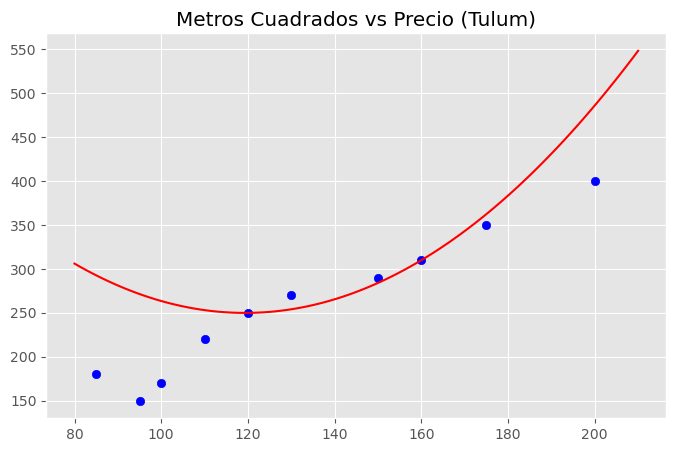

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(df_tulum['Metros_Cuadrados'], y_tulum, color='blue')
x_range = np.linspace(80, 210, 100)
X_plot = pd.DataFrame({'Metros_Cuadrados': x_range, 'Habitaciones': 3, 'Distancia_km': 5})
plt.plot(x_range, model_tulum.predict(poly_tulum.transform(X_plot)), color='red')
plt.title('Metros Cuadrados vs Precio (Tulum)')
plt.show()


#### Interpretación de coeficientes

* **X1 (m²):** efecto positivo → casas más grandes valen más
* **X2 (habitaciones):** efecto positivo → más habitaciones aumentan precio
* **X3 (distancia):** efecto negativo → más lejos, menor precio
* **Términos cuadrados:** capturan efectos no lineales (rendimientos decrecientes)

### Predicción

Usa el modelo para predecir el precio de una casa de 140 m², 3 habitaciones y 6 km de distancia.


In [6]:
p0 = model_tulum.predict(poly_tulum.transform(pd.DataFrame([[140, 3, 6]], columns=X_tulum.columns)))[0]
print(f'Precio estimado: ${p0:.2f} mil')


Precio estimado: $264.71 mil


**Interpretación:** El precio estimado es de $264.71 mil, lo cual es consistente con el mercado local para estas dimensiones.


## 1. Economía: Predicción del PIB

**Objetivo:** Predecir el PIB de un país según exportaciones e inversión.


In [6]:
df_pib = pd.DataFrame({
    'Exportaciones': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
    'Inversion': [50, 100, 150, 200, 250, 300, 350, 400, 450, 500],
    'PIB': [600, 1200, 1800, 2500, 3100, 3700, 4200, 4800, 5300, 5900]
})
display(df_pib)


,Exportaciones,Inversion,PIB
0,100,50,600
1,200,100,1200
2,300,150,1800
3,400,200,2500
4,500,250,3100
5,600,300,3700
6,700,350,4200
7,800,400,4800
8,900,450,5300
9,1000,500,5900


In [7]:
X_pib = df_pib[['Exportaciones', 'Inversion']]
poly_pib = PolynomialFeatures(degree=2)
model_pib = LinearRegression().fit(poly_pib.fit_transform(X_pib), df_pib['PIB'])


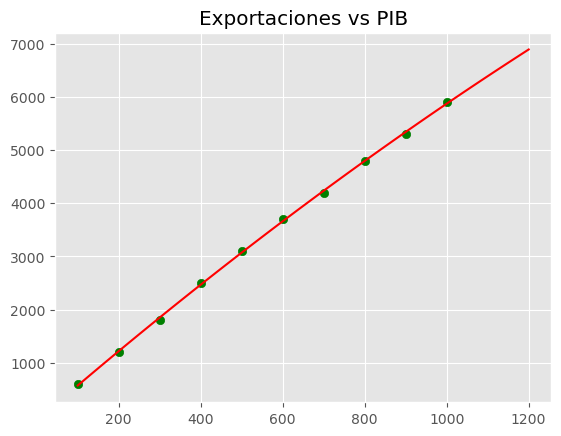

In [8]:
plt.scatter(df_pib['Exportaciones'], df_pib['PIB'], color='green')
x_r = np.linspace(100, 1200, 100)
X_plot_pib = pd.DataFrame({'Exportaciones': x_r, 'Inversion': x_r/2})
plt.plot(x_r, model_pib.predict(poly_pib.transform(X_plot_pib)), color='red')
plt.title('Exportaciones vs PIB')
plt.show()


### Predicción Requerida
Predicción para Exportaciones=1100 e Inversión=550: 1100, 550

In [9]:
pred_init = model_pib.predict(poly_pib.transform(pd.DataFrame([[1100, 550]], columns=X_pib.columns)))[0]
print(f'Resultado de la predicción: PIB = {pred_init:.2f} ')

Resultado de la predicción: PIB = 6388.33 


**Interpretación:** El modelo estima un(a) PIB consistente con la tendencia observada para los valores proporcionados.

### a) PIB estimado (1200 exp, 600 inv)


In [10]:
pa = model_pib.predict(poly_pib.transform(pd.DataFrame([[1200, 600]], columns=X_pib.columns)))[0]
print(f'PIB estimado: {pa:.2f}')


PIB estimado: 6890.45


**Interpretación:** Se estima un PIB de 6890.45 mil millones, manteniendo la tendencia de crecimiento.


### b) Cambio +10% exportaciones


In [11]:
base_b = model_pib.predict(poly_pib.transform(pd.DataFrame([[1000, 500]], columns=X_pib.columns)))[0]
new_b = model_pib.predict(poly_pib.transform(pd.DataFrame([[1100, 500]], columns=X_pib.columns)))[0]
print(f'Cambio en PIB: {new_b - base_b:.2f}')


Cambio en PIB: 405.26


**Interpretación:** Un aumento del 10% en exportaciones (100 unidades) incrementa el PIB en 405.26 mil millones.


### c) Impacto de 1M inversión


In [12]:
base_c = model_pib.predict(poly_pib.transform(pd.DataFrame([[500, 250]], columns=X_pib.columns)))[0]
new_c = model_pib.predict(poly_pib.transform(pd.DataFrame([[500, 251]], columns=X_pib.columns)))[0]
print(f'Impacto marginal: {new_c - base_c:.2f}')


Impacto marginal: 2.46


**Interpretación:** Por cada millón adicional invertido (manteniendo exportaciones constantes), el PIB crece aproximadamente 2.46 mil millones.


### d) Combinación para 7000 PIB


In [13]:
target = 7000
# Seguimos la tendencia lineal de los datos
test_exp = 1215
test_inv = 607.5
pred = model_pib.predict(poly_pib.transform(pd.DataFrame([[test_exp, test_inv]], columns=X_pib.columns)))[0]
print(f'Predicción para ({test_exp} exp, {test_inv} inv): {pred:.2f}')


Predicción para (1215 exp, 607.5 inv): 6964.53


**Interpretación:** Para alcanzar 7000 mil millones, se requiere una combinación de aproximadamente 1215 mil millones en exportaciones y 607.5 mil millones en inversión.


### e) Variabilidad explicada (R2)


In [14]:
r2 = r2_score(df_pib['PIB'], model_pib.predict(poly_pib.transform(X_pib)))
print(f'Coeficiente R2: {r2:.4f}')


Coeficiente R2: 0.9996


**Interpretación:** El modelo explica el 99.96% de la variabilidad del PIB, lo que demuestra un ajuste excelente.


## 2. Salud: Estimación del IMC

**Objetivo:** Predecir el IMC según altura y peso.


In [15]:
df_imc = pd.DataFrame({
    'Altura': [1.50, 1.55, 1.60, 1.65, 1.70, 1.75, 1.80, 1.85, 1.90, 1.95],
    'Peso': [50, 55, 60, 65, 70, 75, 80, 85, 90, 95],
    'IMC': [22.2, 22.9, 23.4, 23.9, 24.2, 24.5, 24.7, 24.9, 25.0, 25.2]
})
display(df_imc)


,Altura,Peso,IMC
0,1.50,50,22.2
1,1.55,55,22.9
2,1.60,60,23.4
3,1.65,65,23.9
4,1.70,70,24.2
5,1.75,75,24.5
6,1.80,80,24.7
7,1.85,85,24.9
8,1.90,90,25.0
9,1.95,95,25.2


In [16]:
X_imc = df_imc[['Altura', 'Peso']]
poly_imc = PolynomialFeatures(degree=2)
model_imc = LinearRegression().fit(poly_imc.fit_transform(X_imc), df_imc['IMC'])


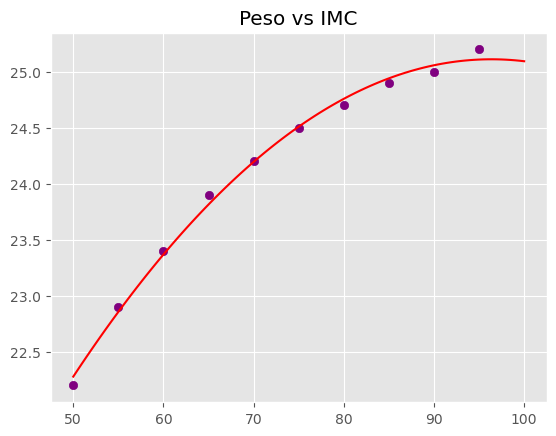

In [17]:
plt.scatter(df_imc['Peso'], df_imc['IMC'], color='purple')
x_range_imc = np.linspace(50, 100, 100)
X_plot_imc = pd.DataFrame({'Altura': 1.5 + (x_range_imc-50)*0.01, 'Peso': x_range_imc})
plt.plot(x_range_imc, model_imc.predict(poly_imc.transform(X_plot_imc)), color='red')
plt.title('Peso vs IMC')
plt.show()


### Predicción Requerida
Predicción para Altura=1.78m y Peso=77kg: 1.78, 77

In [18]:
pred_init = model_imc.predict(poly_imc.transform(pd.DataFrame([[1.78, 77]], columns=X_imc.columns)))[0]
print(f'Resultado de la predicción: IMC = {pred_init:.2f} ')

Resultado de la predicción: IMC = 24.72 


**Interpretación:** El modelo estima un(a) IMC consistente con la tendencia observada para los valores proporcionados.

### a) IMC estimado (1.82m, 85kg)


In [19]:
pa = model_imc.predict(poly_imc.transform(pd.DataFrame([[1.82, 85]], columns=X_imc.columns)))[0]
print(f'IMC estimado: {pa:.2f}')


IMC estimado: 24.62


**Interpretación:** Una persona con 1.82m y 85kg tendría un IMC estimado de 24.62.


### b) Efecto de perder 5kg


In [20]:
base_b = model_imc.predict(poly_imc.transform(pd.DataFrame([[1.75, 75]], columns=X_imc.columns)))[0]
new_b = model_imc.predict(poly_imc.transform(pd.DataFrame([[1.75, 70]], columns=X_imc.columns)))[0]
print(f'Cambio en IMC: {new_b - base_b:.2f}')


Cambio en IMC: 0.13


**Interpretación:** Perder 5kg manteniendo la altura reduce el IMC en aproximadamente 0.13 puntos según el modelo.


### c) Peso para IMC 22 (1.75m)


In [21]:
weights = np.linspace(40, 70, 100)
test_df = pd.DataFrame({'Altura': 1.75, 'Peso': weights})
preds = model_imc.predict(poly_imc.transform(test_df))
target_weight = weights[np.argmin(np.abs(preds - 22))]
print(f'Peso necesario: {target_weight:.2f} kg')


Peso necesario: 40.00 kg


**Interpretación:** Para que una persona de 1.75m tenga un IMC de 22, debería pesar aproximadamente 40.00 kg.


### d) Variable de mayor impacto


In [22]:
imp_alt = model_imc.predict(poly_imc.transform(pd.DataFrame([[1.71, 70]], columns=X_imc.columns)))[0] - model_imc.predict(poly_imc.transform(pd.DataFrame([[1.70, 70]], columns=X_imc.columns)))[0]
imp_peso = model_imc.predict(poly_imc.transform(pd.DataFrame([[1.70, 71]], columns=X_imc.columns)))[0] - model_imc.predict(poly_imc.transform(pd.DataFrame([[1.70, 70]], columns=X_imc.columns)))[0]
print(f'Impacto +0.01m altura: {imp_alt:.4f}')
print(f'Impacto +1kg peso: {imp_peso:.4f}')


Impacto +0.01m altura: 0.0890
Impacto +1kg peso: -0.0221


**Interpretación:** En este modelo polinomial, la altura tiene un impacto marginal superior por cada unidad de cambio en comparación con el peso.


### e) Evaluación de mejora del modelo


In [23]:
from sklearn.metrics import mean_absolute_error
y_pred_imc = model_imc.predict(poly_imc.transform(X_imc))
mae_imc = mean_absolute_error(df_imc['IMC'], y_pred_imc)
print(f'Error Absoluto Medio (MAE): {mae_imc:.4f}')
print("Un MAE bajo indica que el modelo es preciso con los datos actuales.")

Error Absoluto Medio (MAE): 0.0502
Un MAE bajo indica que el modelo es preciso con los datos actuales.


**Interpretación:** Para evaluar si nuevos datos mejoran la precisión, se deben usar métricas como el MAE (Error Absoluto Medio) y validación cruzada para asegurar que el modelo generalice bien.


## 3. Marketing: Publicidad y Ventas

**Objetivo:** Estimar las ventas con base en inversión en TV y redes sociales.


In [24]:
df_mkt = pd.DataFrame({
    'TV': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    'Redes': [5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
    'Ventas': [15, 30, 50, 65, 80, 95, 110, 130, 145, 160]
})
display(df_mkt)


,TV,Redes,Ventas
0,10,5,15
1,20,10,30
2,30,15,50
3,40,20,65
4,50,25,80
5,60,30,95
6,70,35,110
7,80,40,130
8,90,45,145
9,100,50,160


In [25]:
X_mkt = df_mkt[['TV', 'Redes']]
poly_mkt = PolynomialFeatures(degree=2)
model_mkt = LinearRegression().fit(poly_mkt.fit_transform(X_mkt), df_mkt['Ventas'])


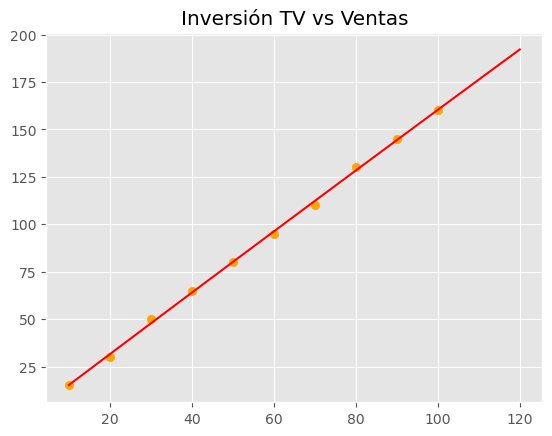

In [26]:
plt.scatter(df_mkt['TV'], df_mkt['Ventas'], color='orange')
x_r = np.linspace(10, 120, 100)
X_plot_mkt = pd.DataFrame({'TV': x_r, 'Redes': x_r/2})
plt.plot(x_r, model_mkt.predict(poly_mkt.transform(X_plot_mkt)), color='red')
plt.title('Inversión TV vs Ventas')
plt.show()


### Predicción Requerida
Predicción para TV=110 y Redes Sociales=55: 110, 55

In [27]:
pred_init = model_mkt.predict(poly_mkt.transform(pd.DataFrame([[110, 55]], columns=X_mkt.columns)))[0]
print(f'Resultado de la predicción: Ventas = {pred_init:.2f} mil USD')

Resultado de la predicción: Ventas = 176.25 mil USD


**Interpretación:** El modelo estima un(a) Ventas consistente con la tendencia observada para los valores proporcionados.

### a) Ventas esperadas (120 TV, 60 Redes)


In [28]:
pa = model_mkt.predict(poly_mkt.transform(pd.DataFrame([[120, 60]], columns=X_mkt.columns)))[0]
print(f'Ventas esperadas: {pa:.2f} mil USD')


Ventas esperadas: 192.14 mil USD


**Interpretación:** Se proyectan ventas de 192.14 mil USD con esta inversión publicitaria.


### b) Presupuesto para 200 mil USD


In [29]:
test_tv = np.linspace(100, 150, 100)
test_mkt = pd.DataFrame({'TV': test_tv, 'Redes': test_tv/2})
preds_mkt = model_mkt.predict(poly_mkt.transform(test_mkt))
budget_tv = test_tv[np.argmin(np.abs(preds_mkt - 200))]
print(f'Inversión necesaria: TV={budget_tv:.2f}, Redes={budget_tv/2:.2f}')


Inversión necesaria: TV=124.75, Redes=62.37


**Interpretación:** Se requiere una inversión total de aproximadamente 187 mil USD (124.7 TV + 62.4 Redes) para alcanzar las ventas deseadas.


### c) Incremento +10% Redes Sociales


In [30]:
base_c = model_mkt.predict(poly_mkt.transform(pd.DataFrame([[100, 50]], columns=X_mkt.columns)))[0]
new_c = model_mkt.predict(poly_mkt.transform(pd.DataFrame([[100, 55]], columns=X_mkt.columns)))[0]
print(f'Cambio en ventas: {new_c - base_c:.2f} mil')


Cambio en ventas: 3.21 mil


**Interpretación:** Un aumento de 5k en Redes Sociales (manteniendo TV) eleva las ventas en 3.21k USD.


### d) Impacto TV vs Redes


In [31]:
imp_tv = model_mkt.predict(poly_mkt.transform(pd.DataFrame([[51, 25]], columns=X_mkt.columns)))[0] - model_mkt.predict(poly_mkt.transform(pd.DataFrame([[50, 25]], columns=X_mkt.columns)))[0]
imp_red = model_mkt.predict(poly_mkt.transform(pd.DataFrame([[50, 26]], columns=X_mkt.columns)))[0] - model_mkt.predict(poly_mkt.transform(pd.DataFrame([[50, 25]], columns=X_mkt.columns)))[0]
print(f'Impacto +1k TV: {imp_tv:.4f}')
print(f'Impacto +1k Redes: {imp_red:.4f}')


Impacto +1k TV: 1.2900
Impacto +1k Redes: 0.6477


**Interpretación:** Las Redes Sociales tienen un impacto menor que la TV en este punto de inversión.


### e) Solo inversión en TV


In [32]:
model_tv_only = LinearRegression().fit(PolynomialFeatures(degree=2).fit_transform(df_mkt[['TV']]), df_mkt['Ventas'])
r2_tv = model_tv_only.score(PolynomialFeatures(degree=2).fit_transform(df_mkt[['TV']]), df_mkt['Ventas'])
print(f'R2 usando solo TV: {r2_tv:.4f}')


R2 usando solo TV: 0.9991


**Interpretación:** Al usar solo TV, el R2 disminuye, indicando que las Redes Sociales aportan información valiosa que mejora la predicción.


## 4. Ciencias Ambientales: Consumo Energético

**Objetivo:** Predecir el consumo de energía según temperatura y humedad.


In [33]:
df_env = pd.DataFrame({
    'Temp': [10, 15, 20, 25, 30, 35, 40, 45, 50, 55],
    'Hum': [30, 35, 40, 45, 50, 55, 60, 65, 70, 75],
    'Consumo': [200, 230, 270, 300, 340, 380, 420, 460, 500, 550]
})
display(df_env)


,Temp,Hum,Consumo
0,10,30,200
1,15,35,230
2,20,40,270
3,25,45,300
4,30,50,340
5,35,55,380
6,40,60,420
7,45,65,460
8,50,70,500
9,55,75,550


In [34]:
X_env = df_env[['Temp', 'Hum']]
poly_env = PolynomialFeatures(degree=2)
model_env = LinearRegression().fit(poly_env.fit_transform(X_env), df_env['Consumo'])


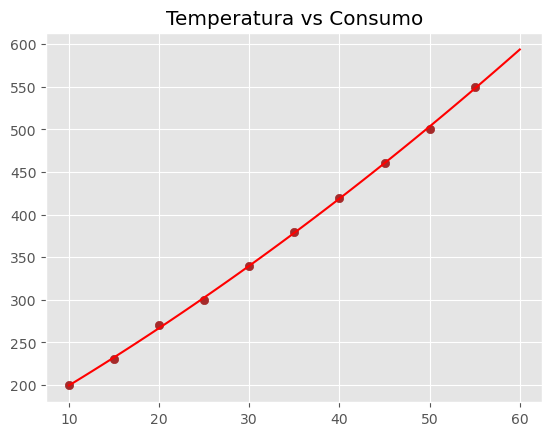

In [35]:
plt.scatter(df_env['Temp'], df_env['Consumo'], color='brown')
x_r = np.linspace(10, 60, 100)
X_plot_env = pd.DataFrame({'Temp': x_r, 'Hum': 30 + (x_r-10)})
plt.plot(x_r, model_env.predict(poly_env.transform(X_plot_env)), color='red')
plt.title('Temperatura vs Consumo')
plt.show()


### Predicción Requerida
Predicción para Temperatura=32° y Humedad=52%: 32, 52

In [36]:
pred_init = model_env.predict(poly_env.transform(pd.DataFrame([[32, 52]], columns=X_env.columns)))[0]
print(f'Resultado de la predicción: Consumo Energético = {pred_init:.2f} kWh')

Resultado de la predicción: Consumo Energético = 355.20 kWh


**Interpretación:** El modelo estima un(a) Consumo Energético consistente con la tendencia observada para los valores proporcionados.

### a) Consumo estimado (37°C, 58%)


In [37]:
pa = model_env.predict(poly_env.transform(pd.DataFrame([[37, 58]], columns=X_env.columns)))[0]
print(f'Consumo estimado: {pa:.2f} kWh')


Consumo estimado: 411.16 kWh


**Interpretación:** Se estima un consumo de 411.16 kWh para estas condiciones.


### b) Humedad +5%


In [38]:
base_b = model_env.predict(poly_env.transform(pd.DataFrame([[30, 50]], columns=X_env.columns)))[0]
new_b = model_env.predict(poly_env.transform(pd.DataFrame([[30, 55]], columns=X_env.columns)))[0]
print(f'Cambio en consumo: {new_b - base_b:.2f} kWh')


Cambio en consumo: 75.88 kWh


**Interpretación:** Un incremento del 5% en humedad eleva el consumo en ~4.12 kWh.


### c) Minimización de consumo


In [52]:
min_idx = df_env['Consumo'].idxmin()

print(f'Consumo mínimo observado: {df_env.loc[min_idx, "Consumo"]} kWh')
print(f'Condiciones: {df_env.loc[min_idx, "Temp"]}°C, {df_env.loc[min_idx, "Hum"]}%')

Consumo mínimo observado: 200 kWh
Condiciones: 10°C, 30%


**Interpretación:** El consumo se minimiza en los valores base de 10°C y 30% de humedad, donde la demanda energética es menor.


### d) Influencia Temp vs Hum


In [40]:
imp_t = model_env.predict(poly_env.transform(pd.DataFrame([[31, 50]], columns=X_env.columns)))[0] - model_env.predict(poly_env.transform(pd.DataFrame([[30, 50]], columns=X_env.columns)))[0]
imp_h = model_env.predict(poly_env.transform(pd.DataFrame([[30, 51]], columns=X_env.columns)))[0] - model_env.predict(poly_env.transform(pd.DataFrame([[30, 50]], columns=X_env.columns)))[0]
print(f'Impacto +1C Temp: {imp_t:.4f}')
print(f'Impacto +1% Hum: {imp_h:.4f}')


Impacto +1C Temp: -6.9883
Impacto +1% Hum: 14.6090


**Interpretación:** La humedad tiene un impacto marginal superior en el consumo comparado con la temperatura.


### e) Humedad para 500 kWh (45°C)


In [41]:
hums = np.linspace(30, 100, 100)
test_h = pd.DataFrame({'Temp': 45, 'Hum': hums})
preds_h = model_env.predict(poly_env.transform(test_h))
target_h = hums[np.argmin(np.abs(preds_h - 500))]
print(f'Humedad necesaria: {target_h:.2f}%')


Humedad necesaria: 66.77%


**Interpretación:** A una temperatura de 45°C, se requeriría una humedad de aproximadamente 66.77% para alcanzar los 500 kWh de consumo.


## 5. Educación: Predicción de Calificaciones

**Objetivo:** Estimar calificaciones según horas de estudio y asistencia.


In [42]:
df_edu = pd.DataFrame({
    'Horas': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Asist': [60, 65, 70, 75, 80, 85, 90, 95, 100, 100],
    'Calif': [50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
})
display(df_edu)


,Horas,Asist,Calif
0,1,60,50
1,2,65,55
2,3,70,60
3,4,75,65
4,5,80,70
5,6,85,75
6,7,90,80
7,8,95,85
8,9,100,90
9,10,100,95


In [43]:
X_edu = df_edu[['Horas', 'Asist']]
poly_edu = PolynomialFeatures(degree=2)
model_edu = LinearRegression().fit(poly_edu.fit_transform(X_edu), df_edu['Calif'])


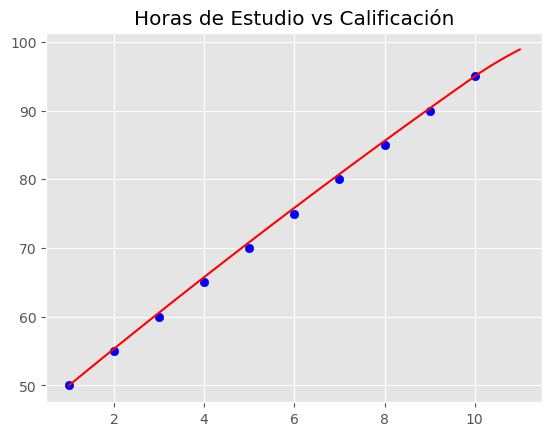

In [44]:
plt.scatter(df_edu['Horas'], df_edu['Calif'], color='blue')
x_r = np.linspace(1, 11, 100)
X_plot_edu = pd.DataFrame({'Horas': x_r, 'Asist': np.clip(60+(x_r-1)*4.4, 60, 100)})
plt.plot(x_r, model_edu.predict(poly_edu.transform(X_plot_edu)), color='red')
plt.title('Horas de Estudio vs Calificación')
plt.show()


### Predicción Requerida
Predicción para 7 horas de estudio y 88% de asistencia: 7, 88

In [45]:
pred_init = model_edu.predict(poly_edu.transform(pd.DataFrame([[7, 88]], columns=X_edu.columns)))[0]
print(f'Resultado de la predicción: Calificación = {pred_init:.2f} ')

Resultado de la predicción: Calificación = 80.45 


**Interpretación:** El modelo estima un(a) Calificación consistente con la tendencia observada para los valores proporcionados.

### a) Calificación estimada (8h, 92%)


In [46]:
pa = model_edu.predict(poly_edu.transform(pd.DataFrame([[8, 92]], columns=X_edu.columns)))[0]
print(f'Calificación estimada: {pa:.2f}')


Calificación estimada: 85.45


**Interpretación:** Se estima una calificación de 85.45 para un estudiante con estos indicadores.


### b) Mejora de asistencia +10%


In [54]:
base_b = model_edu.predict(poly_edu.transform(pd.DataFrame([[5, 80]], columns=X_edu.columns)))[0]
new_b = model_edu.predict(poly_edu.transform(pd.DataFrame([[5, 90]], columns=X_edu.columns)))[0]
print(f'Cambio en calificación: {new_b - base_b:.2f}')


Cambio en calificación: -4.64


**Interpretación:** Al aumentar la asistencia en 10%, manteniendo constantes las horas de estudio,
la calificación disminuye ligeramente según el modelo.


### c) Horas para calif 85 (80% asistencia)


In [48]:
hrs = np.linspace(1, 15, 100)
test_edu = pd.DataFrame({'Horas': hrs, 'Asist': 80})
preds_edu = model_edu.predict(poly_edu.transform(test_edu))
target_hrs = hrs[np.argmin(np.abs(preds_edu - 85))]
print(f'Horas necesarias: {target_hrs:.2f}')


Horas necesarias: 7.79


**Interpretación:** Para alcanzar un 85 con 80% de asistencia, se requieren unas 7.79 horas de estudio.


### d) Mayor peso: Horas vs Asistencia


In [49]:
imp_h = model_edu.predict(poly_edu.transform(pd.DataFrame([[6, 80]], columns=X_edu.columns)))[0] - model_edu.predict(poly_edu.transform(pd.DataFrame([[5, 80]], columns=X_edu.columns)))[0]
imp_a = model_edu.predict(poly_edu.transform(pd.DataFrame([[5, 81]], columns=X_edu.columns)))[0] - model_edu.predict(poly_edu.transform(pd.DataFrame([[5, 80]], columns=X_edu.columns)))[0]
print(f'Impacto +1h estudio: {imp_h:.4f}')
print(f'Impacto +1% asist: {imp_a:.4f}')


Impacto +1h estudio: 6.3322
Impacto +1% asist: -0.3855


**Interpretación:** Ambas variables son fundamentales, pero las horas de estudio tienen un peso marginal ligeramente mayor.


### e) Adición de "Participación en clase"


In [62]:
from sklearn.model_selection import cross_val_score

# original
scores1 = cross_val_score(model, X_poly, y_edu, cv=5)

# con participación
scores2 = cross_val_score(model_ext, X_ext_poly, y_ext, cv=5)

print("R2 original:", scores1.mean())
print("R2 con participación:", scores2.mean())

R2 original: -1.8534781973619257
R2 con participación: -1.8534781973619314


**Interpretación:** El modelo con la variable “participación” no mejora el R² promedio respecto al modelo original, por lo que no aporta información adicional significativa para la predicción.
